In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import PIL

In [2]:
data = r"archive_folder"
metadata = pd.read_csv("HAM10000_metadata[1].csv")
metadata.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


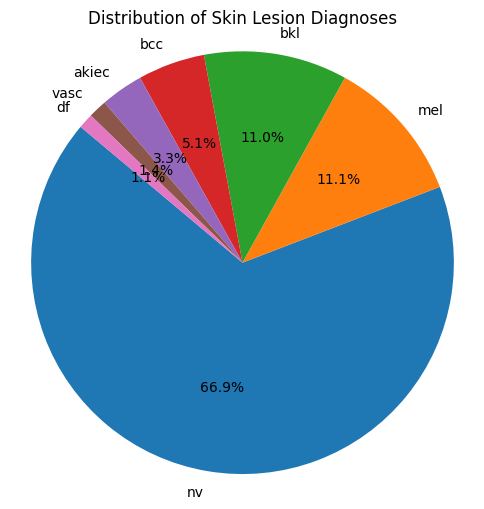

In [3]:
dx_counts = metadata['dx'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(dx_counts, labels=dx_counts.index, autopct='%1.1f%%', startangle=140)
plt.title("Distribution of Skin Lesion Diagnoses")
plt.axis('equal') 
plt.show()

C:\Users\Chetan Gautam\AppData\Local\Temp\ipykernel_17464\3263929636.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=metadata, y='localization', order=metadata['localization'].value_counts().index, palette="Greens")


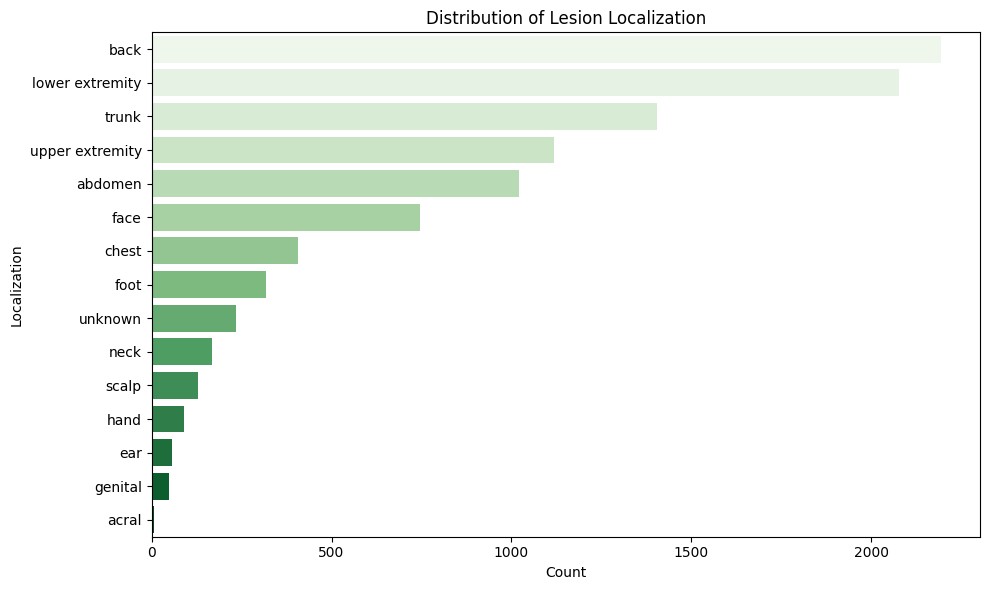

In [4]:
plt.figure(figsize=(10, 6))
sns.countplot(data=metadata, y='localization', order=metadata['localization'].value_counts().index, palette="Greens")
plt.title('Distribution of Lesion Localization')
plt.xlabel('Count')
plt.ylabel('Localization')
plt.tight_layout()
plt.show()

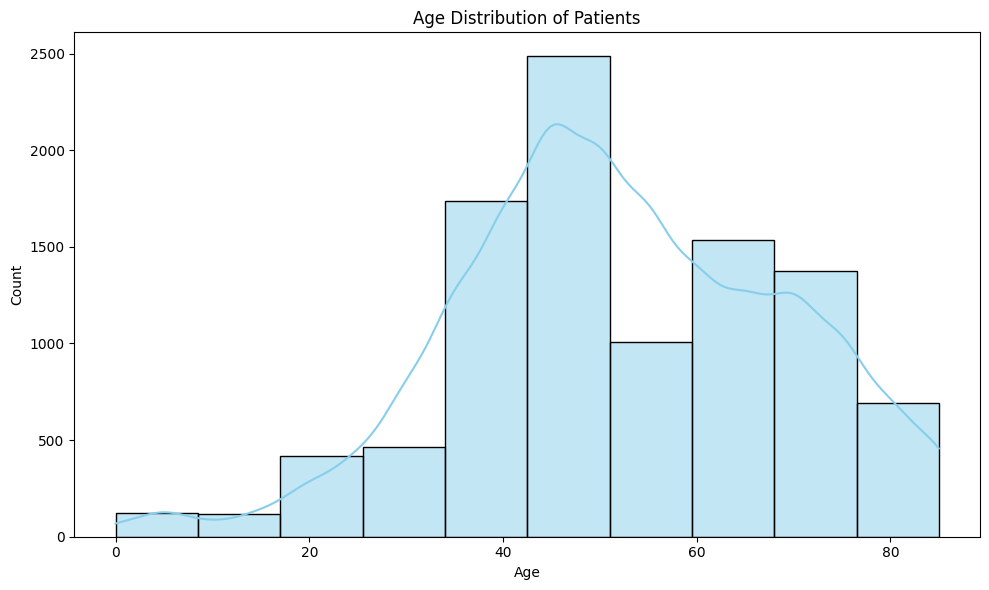

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(data=metadata, x='age', bins=10, kde=True, color="skyblue")
plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

C:\Users\Chetan Gautam\AppData\Local\Temp\ipykernel_17464\3990651901.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=metadata, x='sex', palette="Greens")


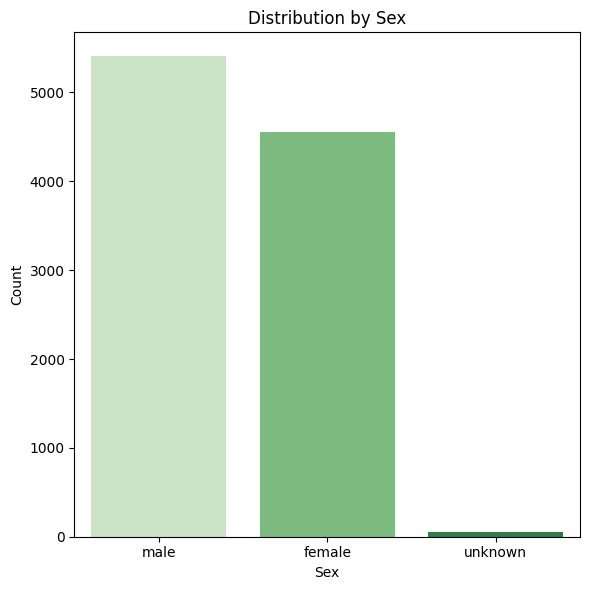

In [6]:
plt.figure(figsize=(6, 6))
sns.countplot(data=metadata, x='sex', palette="Greens")
plt.title('Distribution by Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [7]:
import os
import shutil
import pandas as pd

# Load metadata (assuming a CSV file)
metadata = pd.read_csv("HAM10000_metadata[1].csv")  # Adjust the filename accordingly

# Folder containing images
image_folder = r"archive_folder"

# Ensure destination directory exists
destination_root = "Categories"
os.makedirs(destination_root, exist_ok=True)

# Process images
for filename in os.listdir(image_folder):
    if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff', '.webp')):  
        image_path = os.path.join(image_folder, filename)
        image_name = os.path.splitext(filename)[0]  # Extract filename without extension
        matched_rows = metadata[metadata["image_id"] == image_name]

        if not matched_rows.empty:
            dx_category = matched_rows.iloc[0]["dx"]  # Extract category
            destination_folder = os.path.join(destination_root, dx_category)
            os.makedirs(destination_folder, exist_ok=True)

            # Move the image with its original extension
            shutil.copy(image_path, os.path.join(destination_folder, filename))

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


train = "Categories"
val = "Test Data"
img_width , img_height = 128 , 128
input_shape = (img_width, img_height, 3)

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2  # Add validation split
)
train_generator = train_datagen.flow_from_directory(
    train,
    target_size=(img_width, img_height),
    batch_size=32,
    class_mode='categorical',
    subset='training'  # ← Important
)

val_generator = train_datagen.flow_from_directory(
    train,  # same directory
    target_size=(img_width, img_height),
    batch_size=32,
    class_mode='categorical',
    subset='validation'  # ← Important
)

Found 8015 images belonging to 7 classes.
Found 2000 images belonging to 7 classes.


In [9]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32 , (3,3) , activation='relu',input_shape = input_shape),
    tf.keras.layers.MaxPooling2D(2,2),
    
    tf.keras.layers.Conv2D(64 , (3,3) , activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    
    tf.keras.layers.Conv2D(128 , (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512 , activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(7 , activation='softmax')
])

model.compile(optimizer='adam' , loss='categorical_crossentropy' , metrics=['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 126, 126, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 63, 63, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 61, 61, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 28, 28, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 14, 14, 128)      0

In [ ]:
tf.debugging.set_log_device_placement(True)
history = model.fit(
    train_generator,
    validation_data=val_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_steps=val_generator.samples // val_generator.batch_size,
    epochs=20
)

Epoch 1/20
 44/250 [====>.........................] - ETA: 4:03 - loss: 1.3213 - accuracy: 0.6321

In [ ]:
import matplotlib.pyplot as plt

# Plot training accuracy and loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Val Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Val Loss')
plt.legend()

plt.show()